In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


In [73]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [75]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [76]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


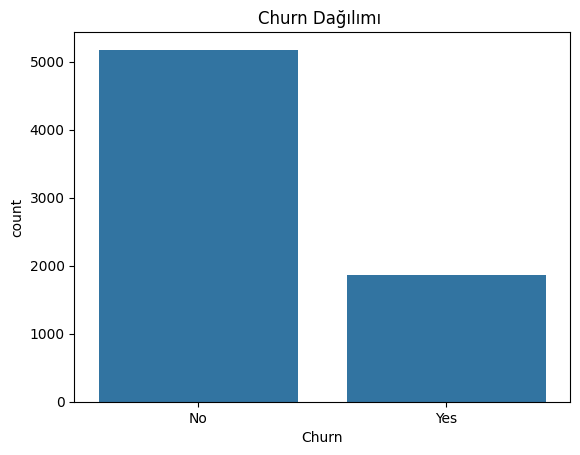

In [77]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Dağılımı ")
plt.show()


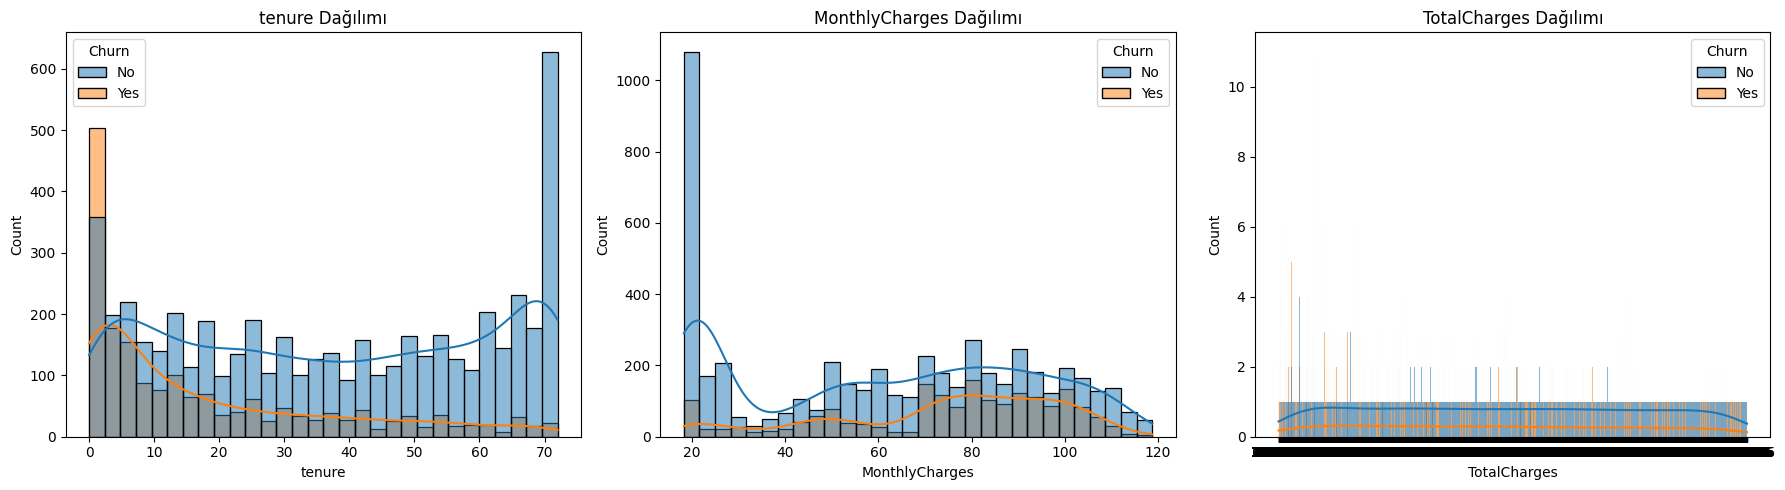

In [78]:
# Sayısal değişkenlerin dağılımı
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, bins=30)
    ax.set_title(f"{col} Dağılımı")
plt.tight_layout()
plt.show()


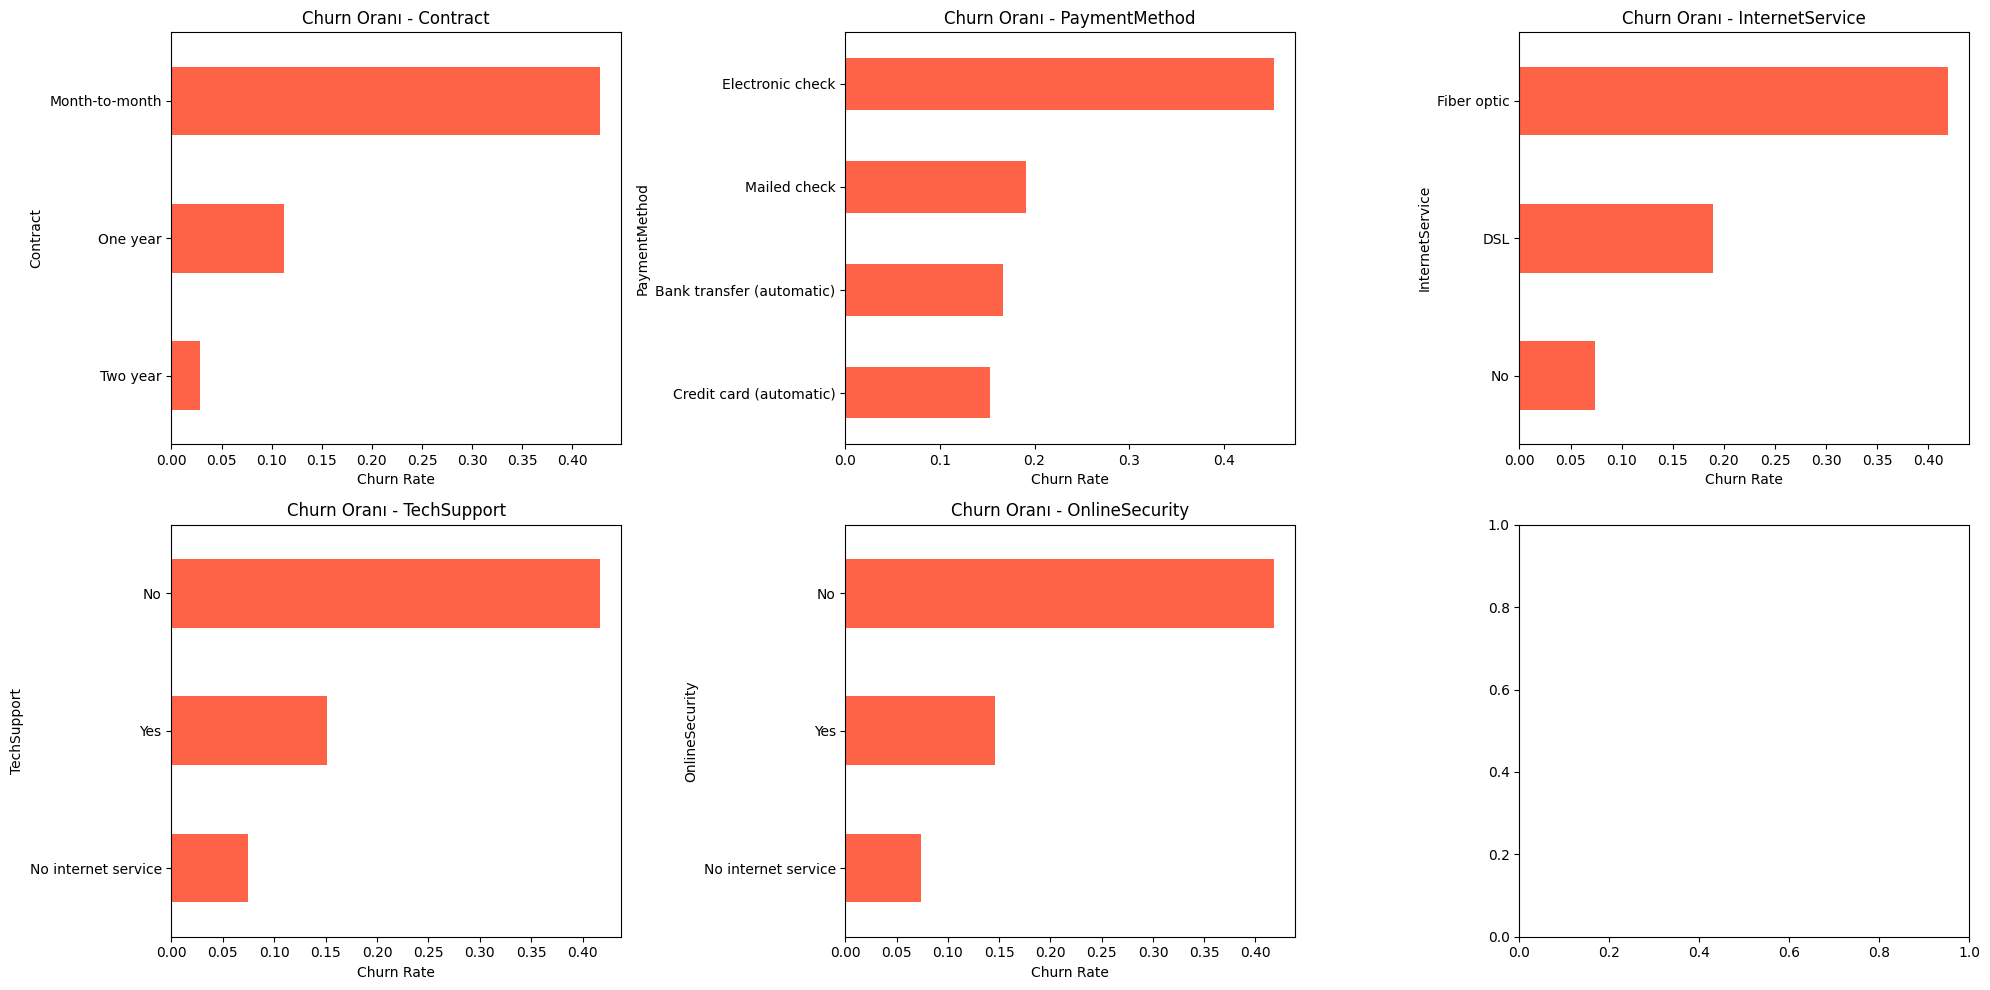

In [79]:
# Kategorik değişkenlere göre churn oranı
cat_cols = ["Contract", "PaymentMethod", "InternetService", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    churn_by_cat = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_by_cat.sort_values().plot(kind="barh", ax=ax, color="tomato")
    ax.set_title(f"Churn Oranı - {col}")
    ax.set_xlabel("Churn Rate")
plt.tight_layout()
plt.show()


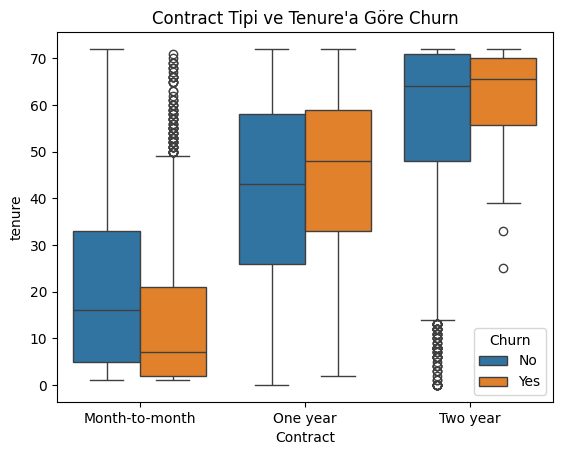

In [82]:
# %%
# Contract tipine göre tenure dağılımı - churn ile ilişkisini gözlemleme
sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn")
plt.title("Contract Tipi ve Tenure'a Göre Churn")
plt.show()